In [ ]:
# Conditional Multimodal MRI Synthesis and and Brain Tumor Segmentation

Author: Hamdan Tariq  
Copyright 2026 Hamdan Tariq

Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# **Meta-Data Path**

In [1]:
csv_path = '/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS20 Training Metadata.csv'

In [2]:
import pandas as pd
df = pd.read_csv(csv_path)
df['slice_path'] = df['slice_path'].str.replace( '../input/brats2020-training-data',
    '/kaggle/input/datasets/awsaf49/brats2020-training-data')

In [3]:
print(df.shape)
df.head()
kept = len(df[df['background_ratio'] < 0.95])
lost = len(df) - kept
print(f"Keeping {kept} slices, removing {lost} empty slices.")

(57195, 8)
Keeping 3544 slices, removing 53651 empty slices.


# **Total black slices**

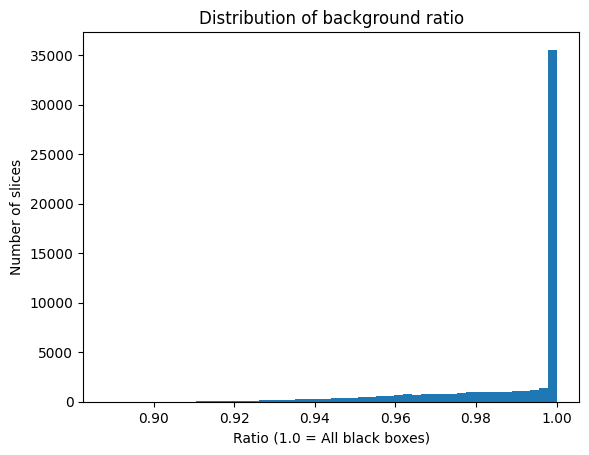

In [4]:
import matplotlib.pyplot as plt
plt.hist(df['background_ratio'],bins = 50)
plt.title('Distribution of background ratio')
plt.xlabel('Ratio (1.0 = All black boxes)')
plt.ylabel('Number of slices')
plt.show()

# **Cleaning Useless slices**

In [5]:
cleaned_df = df[df['background_ratio'] < 0.95]

In [6]:
cleaned_df.shape

(3544, 8)

In [7]:
cleaned_df.head()

,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
386,/kaggle/input/datasets/awsaf49/brats2020-train...,1,135,76,1189,1430,429,0.947083
387,/kaggle/input/datasets/awsaf49/brats2020-train...,1,135,77,1223,1535,540,0.942743
388,/kaggle/input/datasets/awsaf49/brats2020-train...,1,135,78,1267,1590,635,0.939375
389,/kaggle/input/datasets/awsaf49/brats2020-train...,1,135,79,1279,1592,823,0.935868
390,/kaggle/input/datasets/awsaf49/brats2020-train...,1,135,80,1332,1542,922,0.934097


In [8]:
print(f"Total Patients remaining: {cleaned_df['volume'].nunique()}")
patients_slices_count = pd.DataFrame(
        cleaned_df.groupby('volume').size().reset_index(name='Slices').rename(columns={'volume': 'Patient Id'})
)
print(patients_slices_count[patients_slices_count['Patient Id'] == 41])
print(patients_slices_count.head(100))
# Conforming if mapping is correct
print(df[df['volume'] == 2][df['background_ratio'] < 0.95].count())

Total Patients remaining: 136
Empty DataFrame
Columns: [Patient Id, Slices]
Index: []
    Patient Id  Slices
0            1      40
1            6      13
2            9      28
3           16      15
4           20      29
..         ...     ...
95         281      19
96         284      38
97         285      11
98         289      36
99         290      38

[100 rows x 2 columns]
slice_path          0
target              0
volume              0
slice               0
label0_pxl_cnt      0
label1_pxl_cnt      0
label2_pxl_cnt      0
background_ratio    0
dtype: int64


/tmp/ipykernel_57/4261175285.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df['volume'] == 2][df['background_ratio'] < 0.95].count())


# **Visualizing One whole 3D scan**

In [9]:
import h5py
import numpy as np
patient_id = 40
volume_slices = []
for patient_path in df[df['volume'] == patient_id]['slice_path']:
  with h5py.File(patient_path,'r') as  f: # r makes it super fast
    image_slice = f['image'][()] # tells Python to read the entire dataset into memory right now.
    volume_slices.append(image_slice)

full_volume = np.stack(volume_slices,axis = 0) # if inside loop same result because dim will be different
print(f"Reconstructed 3D volume: {full_volume.shape}")

Reconstructed 3D volume: (155, 240, 240, 4)


In [10]:
from ipywidgets import interact
def visualize_3d_volume(volume):
  def i_slice(z):
    plt.figure(figsize=(8, 8))
    plt.imshow(volume[z, :, :], cmap='bone')
    plt.title(f"Patient {patient_id} - Slice {z}")
    plt.axis('off')
    plt.show()
  interact(i_slice, z=(0, volume.shape[0] - 1))

visualize_3d_volume(full_volume)


interactive(children=(IntSlider(value=77, description='z', max=154), Output()), _dom_classes=('widget-interact…

In [11]:
def load_patient_full(df, patient_id):
    patient_df = df[df['volume'] == patient_id].sort_values(by='slice')

    # Store everything as 4D/"3D arrays
    # Modalities: (Slices, 240, 240, 4)
    # Masks: (Slices, 240, 240, 3)
    temp_imgs = []
    temp_msks = []

    for path in patient_df['slice_path']:
        with h5py.File(path, 'r') as f:
            temp_imgs.append(f['image'][()])
            temp_msks.append(f['mask'][()])

    return np.stack(temp_imgs), np.stack(temp_msks)

# Usage
imgs, msks = load_patient_full(df, 40)

In [12]:
def visualize_comparison(z):
    fig, axes = plt.subplots(1, 7, figsize=(25, 5))

    # Titles and color maps
    titles = ['FLAIR', 'T1', 'T1ce', 'T2', 'Core (NCR)', 'Edema (ED)', 'Enhancing (ET)']
    cmaps = ['gray', 'gray', 'gray', 'gray', 'Reds', 'Greens', 'Blues']

    # Plot 4 Modalities
    for i in range(4):
        axes[i].imshow(imgs[z, :, :, i], cmap='gray')
        axes[i].set_title(titles[i])

    # Plot 3 Mask Channels
    for i in range(3):
        # We use vmin/vmax to ensure the binary 1s show up bright
        axes[i+4].imshow(msks[z, :, :, i], cmap=cmaps[i+4], vmin=0, vmax=1)
        axes[i+4].set_title(titles[i+4])

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

interact(visualize_comparison, z=(0, imgs.shape[0] - 1))

interactive(children=(IntSlider(value=77, description='z', max=154), Output()), _dom_classes=('widget-interact…

<function __main__.visualize_comparison(z)>

# **Training-Data cleaning**

In [ ]:
import os
import shutil

# 1. Define paths
input_path = '/kaggle/input/models/hamdantariq/diffusion-model-v2/pytorch/default/1/checkpoints/latest_checkpoint_v9.pt'
output_dir = '/kaggle/working/checkpoints'
output_path = os.path.join(output_dir, 'latest_checkpoint_v9.pt')

# 2. Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 3. Copy the file
if os.path.exists(input_path):
    shutil.copy(input_path, output_path)
    print(f"✅ Success! Checkpoint copied to: {output_path}")
else:
    print(f"❌ Error: Could not find the file at {input_path}")
    print("Please double-check the path in your 'Data' sidebar.")

In [3]:
import glob
import os
def find_dataset_paths():
    csv_files = glob.glob('/kaggle/input/**/BraTS20 Training Metadata.csv', recursive=True)
    if not csv_files: csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
    if not csv_files: raise FileNotFoundError("Could not find Metadata CSV!")
    csv_path = csv_files[0]
    root_dir = os.path.dirname(csv_path)
    print(f"📂 Found Metadata: {csv_path}")
    return csv_path, root_dir

csv_path, root_dir = find_dataset_paths()
print(csv_path,root_dir)

📂 Found Metadata: /kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS20 Training Metadata.csv
/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS20 Training Metadata.csv /kaggle/input/datasets/awsaf49/brats2020-training-data


In [ ]:
import os, gc, contextlib, random, time, glob
import numpy as np
import pandas as pd
import h5py
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

os.environ['PJRT_DEVICE'] = 'TPU'
os.environ['XLA_USE_BF16'] = '0'
os.environ['XLA_TPU_ALLOCATOR_FRACTION'] = '0.90'

import torch #for loading tensors
import torch.nn as nn # for layers like convolutional
import torch.nn.functional as F # for functions like mean squared error
import torchvision # for loading perceptual loss
import torchvision.transforms.functional as TF # transform functional -> from 240x240 to 128x128 and to flip them

import torch_xla 
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl # to reduce massive bottle necks while sending data from harddisk to TPU
import torch_xla.distributed.xla_multiprocessing as xmp #allows to run 8 parralel processing units
import torch_xla.runtime as xr

from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler # each gets different batch of data
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
# actual neural network for denosing -> predict nosie
# adds guasian noise to mri scans gradually over 1000 steps
# generates an clear high quality image in only 50 steps

# =============================================================================
# AUTO-PATH DISCOVERY
# =============================================================================
def find_dataset_paths():
    csv_files = glob.glob('/kaggle/input/**/BraTS20 Training Metadata.csv', recursive=True)
    if not csv_files: csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
    if not csv_files: raise FileNotFoundError("Could not find Metadata CSV!")
    csv_path = csv_files[0]
    root_dir = os.path.dirname(csv_path)
    print(f"📂 Found Metadata: {csv_path}")
    return csv_path, root_dir

# =============================================================================
# CUSTOM CPU-EMA 
# =============================================================================
# sample_with_cfg
class CPUEMA:
    def __init__(self, model, decay=0.9990):
        self.decay, self.num_updates = decay, 0
        self.shadow = [p.detach().float().cpu().clone() for p in model.parameters()]
        self._stored = None
    def update(self, model):
        d = min(self.decay, (1 + self.num_updates) / (10 + self.num_updates))
        with torch.no_grad():
            for shadow, param in zip(self.shadow, model.parameters()):
                shadow.mul_(d).add_(param.detach().float().cpu(), alpha=1.0 - d)
        self.num_updates += 1
    def copy_to(self, model):
        with torch.no_grad():
            for shadow, param in zip(self.shadow, model.parameters()):
                param.copy_(shadow.to(device=param.device, dtype=param.dtype))
    def store(self, model): self._stored = [p.detach().cpu().clone() for p in model.parameters()]
    def restore(self, model):
        if self._stored:
            with torch.no_grad():
                for stored, param in zip(self._stored, model.parameters()):
                    param.copy_(stored.to(device=param.device, dtype=param.dtype))
        self._stored = None
    @contextlib.contextmanager
    def average_parameters(self, model):
        self.store(model); self.copy_to(model)
        try: yield
        finally: self.restore(model)
    def state_dict(self): return {'shadow': self.shadow, 'num_updates': self.num_updates}
    def load_state_dict(self, sd): self.shadow = sd['shadow']; self.num_updates = sd['num_updates']

# =============================================================================
# LOSS: Perceptual (VGG16) + SSIM
# =============================================================================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        blocks = []
        blocks.append(torchvision.models.vgg16(weights='IMAGENET1K_V1').features[:4].eval())
        blocks.append(torchvision.models.vgg16(weights='IMAGENET1K_V1').features[4:9].eval())
        blocks.append(torchvision.models.vgg16(weights='IMAGENET1K_V1').features[9:16].eval())
        self.blocks = nn.ModuleList(blocks)
        for bl in self.blocks:
            for p in bl.parameters(): p.requires_grad = False
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def forward(self, input, target):
        if input.shape[1] != 3: input, target = input[:, :3, :, :], target[:, :3, :, :]
        input, target = (input + 1.0) / 2.0, (target + 1.0) / 2.0
        input, target = (input - self.mean) / self.std, (target - self.mean) / self.std
        loss = 0.0
        x, y = input, target
        for block in self.blocks:
            x, y = block(x), block(y); loss += F.l1_loss(x, y)
        return loss

def ssim_loss(img1, img2, window_size=11):
    img1_01, img2_01 = (img1 + 1.0) / 2.0, (img2 + 1.0) / 2.0
    channel = img1.size(1)
    window = torch.ones((channel, 1, window_size, window_size), device=img1.device) / (window_size**2)
    mu1 = F.conv2d(img1_01, window, padding=window_size//2, groups=channel)
    mu2 = F.conv2d(img2_01, window, padding=window_size//2, groups=channel)
    mu1_sq, mu2_sq, mu1_mu2 = mu1.pow(2), mu2.pow(2), mu1 * mu2
    sigma1_sq = F.conv2d(img1_01 * img1_01, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2_01 * img2_01, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12   = F.conv2d(img1_01 * img2_01, window, padding=window_size//2, groups=channel) - mu1_mu2
    C1, C2 = 0.01**2, 0.03**2
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return 1 - ssim_map.mean()

# =============================================================================
# CONFIGURATION
# =============================================================================
class Config:
    CSV_PATH, DATA_ROOT = find_dataset_paths()
    SAVE_DIR, SAMPLE_DIR = '/kaggle/working/checkpoints', '/kaggle/working/samples'
    LATEST_PATH = '/kaggle/working/checkpoints/latest_checkpoint_v9.pt'
    IMAGE_SIZE, MRI_CH, MASK_CH, IN_CH, OUT_CH = 128, 4, 4, 8, 4
    BLOCK_CH = (128, 256, 384, 512)
    BATCH_SIZE, LR, NUM_EPOCHS, STABILITY_EPOCH, WARMUP_EPOCHS = 8, 1e-4, 500, 150, 10
    CFG_DROP_PROB, GUIDANCE_SCALE, EMA_DECAY, GRAD_CLIP, PATIENCE = 0.15, 7.5, 0.9990, 1.0, 500    

cfg = Config()
os.makedirs(cfg.SAVE_DIR, exist_ok=True); os.makedirs(cfg.SAMPLE_DIR, exist_ok=True)

# =============================================================================
# DATASET
# =============================================================================
def prepare_mri_target(raw_mri: np.ndarray) -> np.ndarray:
    normalized = np.zeros_like(raw_mri, dtype=np.float32)
    for c in range(raw_mri.shape[0]):
        vol = raw_mri[c]; brain_mask = vol > 0
        if brain_mask.sum() > 10:
            mu, std = vol[brain_mask].mean(), vol[brain_mask].std() + 1e-8
            normalized[c] = np.clip((vol - mu) / std, -5.0, 5.0) / 5.0
        else: normalized[c] = -1.0
    normalized[:, (raw_mri == 0).all(axis=0)] = -1.0
    return normalized

def prepare_mask_condition(raw_mask: np.ndarray) -> np.ndarray:
    label = raw_mask[0] if raw_mask.ndim == 3 else raw_mask
    H, W = label.shape; one_hot = np.zeros((4, H, W), dtype=np.float32)
    one_hot[0], one_hot[1], one_hot[2], one_hot[3] = (label == 1), (label == 2), (label == 4), (label > 0)
    return one_hot

class BratsDiffusionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = True):
        self.df, self.augment = df.reset_index(drop=True), augment
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        try:
            rel_path = self.df.iloc[idx]['slice_path']; filename = os.path.basename(rel_path)
            full_path = glob.glob(f"{os.path.dirname(cfg.DATA_ROOT)}/**/{filename}", recursive=True)[0]
            with h5py.File(full_path, 'r') as f:
                mri = torch.from_numpy(prepare_mri_target(f['image'][()].transpose(2, 0, 1))).float()
                mask = torch.from_numpy(prepare_mask_condition(f['mask'][()].transpose(2, 0, 1))).float()
            mri, mask = TF.resize(mri, [128, 128], antialias=True), TF.resize(mask, [128, 128], antialias=True)
            if self.augment and random.random() > 0.5: mri, mask = TF.hflip(mri), TF.hflip(mask)
            return {"pixel_values": mri, "conditioning_mask": (mask > 0.5).float()}
        except: return self.__getitem__(random.randint(0, len(self.df)-1))

def build_model(cfg: Config):
    base = UNet2DModel(
        sample_size=128, in_channels=cfg.IN_CH, out_channels=cfg.OUT_CH,
        layers_per_block=2, block_out_channels=cfg.BLOCK_CH,
        down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        attention_head_dim=8, resnet_time_scale_shift="scale_shift", dropout=0.1,
    )
    return base

@torch.no_grad()
def sample_with_cfg(model, noise_scheduler, mask, device):
    model.eval(); uncond_mask = torch.zeros_like(mask)
    sched = DDIMScheduler.from_config(noise_scheduler.config)
    sched.set_timesteps(50); latents = torch.randn(mask.shape[0], cfg.MRI_CH, 128, 128, device=device)
    for t in sched.timesteps:
        inp = torch.cat([torch.cat([latents, latents]), torch.cat([uncond_mask, mask])], dim=1)
        out = model(inp, t, return_dict=False)[0]
        pred_u, pred_c = out.chunk(2)
        noise_pred = pred_u + cfg.GUIDANCE_SCALE * (pred_c - pred_u)
        latents = sched.step(noise_pred, t, latents).prev_sample
    model.train(); return latents

def save_comparison_plot(batch_real, batch_gen, batch_mask, epoch, save_dir, num_samples=3):
    def to01(t): return np.clip((t.detach().cpu().float().numpy() + 1.0) / 2.0, 0, 1)
    fig, axes = plt.subplots(num_samples * 4, 3, figsize=(12, 4 * num_samples))
    for s in range(num_samples):
        real_mri, gen, mask = batch_real[s], batch_gen[s], batch_mask[s]
        mask_np = mask.detach().cpu().float().numpy(); mask_rgb = np.stack([mask_np[0], mask_np[1], mask_np[2]], axis=-1)
        for row in range(4):
            ax_idx = s * 4 + row
            axes[ax_idx, 0].imshow(mask_rgb); axes[ax_idx, 1].imshow(to01(real_mri)[row], cmap='gray'); axes[ax_idx, 2].imshow(to01(gen)[row], cmap='gray')
            for a in axes[ax_idx]: a.axis('off')
    plt.tight_layout(); plt.savefig(os.path.join(save_dir, f"epoch_{epoch:03d}.png")); plt.close()

def train_fn(rank, cfg: Config):
    device, world = xm.xla_device(), xr.world_size(); is_master = xm.is_master_ordinal()
    df = pd.read_csv(cfg.CSV_PATH); df = df[df['background_ratio'] < 0.95].copy()
    n_val = int(len(df) * 0.1); train_ds, val_ds = BratsDiffusionDataset(df.iloc[n_val:]), BratsDiffusionDataset(df.iloc[:n_val], False)
    train_sampler = DistributedSampler(train_ds, world, rank, True)
    train_dl = pl.MpDeviceLoader(DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=train_sampler, num_workers=0, drop_last=True), device)
    model = build_model(cfg).to(device); ema = CPUEMA(model, decay=cfg.EMA_DECAY)
    perceptual_loss = VGGPerceptualLoss().to(device)
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2", clip_sample=False, prediction_type="v_prediction")
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-2)
    lr_sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda e: (e+1)/cfg.WARMUP_EPOCHS if e < cfg.WARMUP_EPOCHS else 0.1 if e >= cfg.STABILITY_EPOCH else 0.5*(1+np.cos(np.pi*(e-cfg.WARMUP_EPOCHS)/(cfg.STABILITY_EPOCH-cfg.WARMUP_EPOCHS))))
    
    start_epoch, best_val_loss = 0, float('inf')
    if os.path.exists(cfg.LATEST_PATH):
        ckpt = torch.load(cfg.LATEST_PATH, map_location='cpu', weights_only=False)
        model.load_state_dict(ckpt['model_state_dict']); optimizer.load_state_dict(ckpt['optimizer_state_dict']); ema.load_state_dict(ckpt['ema_state_dict']); start_epoch = ckpt['epoch'] + 1
        xm.rendezvous('resume_sync')

    for epoch in range(start_epoch, cfg.NUM_EPOCHS):
        model.train(); train_sampler.set_epoch(epoch)
        for step, batch in enumerate(train_dl):
            mri, mask = batch["pixel_values"], batch["conditioning_mask"]
            if torch.rand(1).item() < cfg.CFG_DROP_PROB: mask = torch.zeros_like(mask)
            noise, t = torch.randn_like(mri), torch.randint(0, 1000, (mri.shape[0],), device=device).long()
            target = noise_scheduler.get_velocity(mri, noise, t)
            with torch.autocast(device_type='xla', dtype=torch.bfloat16):
                pred = model(torch.cat([noise_scheduler.add_noise(mri, noise, t), mask], dim=1), t, return_dict=False)[0]
                mse_l, ssim_l, perc_l = F.mse_loss(pred, target, reduction='none'), ssim_loss(pred, target), perceptual_loss(pred, target)
                snr = noise_scheduler.alphas_cumprod.to(device)[t] / (1 - noise_scheduler.alphas_cumprod.to(device)[t])
                loss = (torch.clamp(snr, max=5.0).view(-1,1,1,1) * mse_l).mean() + F.l1_loss(pred, target) + 1.0 * ssim_l + 0.1 * perc_l
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP); xm.optimizer_step(optimizer); torch_xla.sync(); ema.update(model); optimizer.zero_grad()
            if step % 50 == 0 and is_master: print(f"Ep {epoch} | MSE:{mse_l.mean():.4f} | SSIM:{ssim_l:.4f} | PERC:{perc_l:.4f}")
        if is_master:
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'ema_state_dict': ema.state_dict(), 'best_val_loss': best_val_loss}, cfg.LATEST_PATH)
            if epoch % 5 == 0:
                with ema.average_parameters(model): gen = sample_with_cfg(model, noise_scheduler, mask[0:3], device)
                save_comparison_plot(mri[0:3], gen[0:3], mask[0:3], epoch, cfg.SAMPLE_DIR)
        lr_sched.step(); gc.collect()

if __name__ == '__main__':
    xmp.spawn(train_fn, args=(cfg,), nprocs=None, start_method='fork')



✅ Convergence graph saved as 'brats_learning_curves.png'


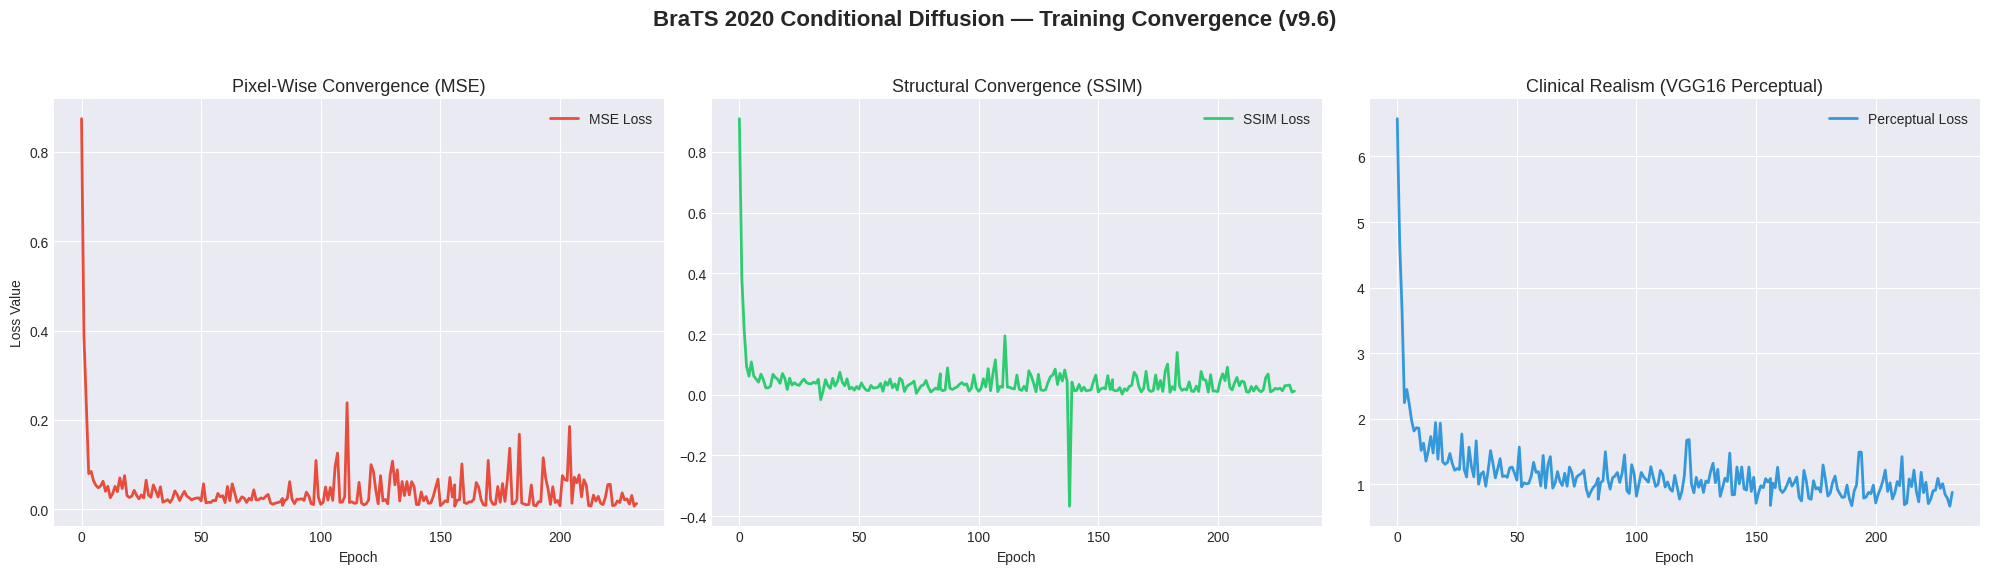

In [33]:
import matplotlib.pyplot as plt
import re
import numpy as np

# I'll use a simplified version of the logs you provided for the parsing logic
# Since you provided a huge list, I'll extract the values using regex
raw_text = """376.6s	291	Ep 0 | MSE:0.8744 | SSIM:0.9097 | PERC:6.5750
1931.1s	292	Ep 1 | MSE:0.3884 | SSIM:0.3882 | PERC:4.6951
2260.2s	293	Ep 2 | MSE:0.2323 | SSIM:0.2132 | PERC:3.6469
2616.4s	294	Ep 3 | MSE:0.0799 | SSIM:0.0934 | PERC:2.2459
2949.5s	295	Ep 4 | MSE:0.0850 | SSIM:0.0612 | PERC:2.4462
3315.3s	296	Ep 5 | MSE:0.0642 | SSIM:0.1079 | PERC:2.2269
3658.4s	297	Ep 6 | MSE:0.0536 | SSIM:0.0618 | PERC:1.9726
3975.0s	298	Ep 7 | MSE:0.0482 | SSIM:0.0515 | PERC:1.8135
4328.0s	299	Ep 8 | MSE:0.0523 | SSIM:0.0412 | PERC:1.8614
4666.0s	300	Ep 9 | MSE:0.0630 | SSIM:0.0678 | PERC:1.8585
5001.7s	301	Ep 10 | MSE:0.0405 | SSIM:0.0500 | PERC:1.5189
5349.7s	302	Ep 11 | MSE:0.0516 | SSIM:0.0230 | PERC:1.6278
5694.6s	303	Ep 12 | MSE:0.0259 | SSIM:0.0221 | PERC:1.3546
6043.2s	304	Ep 13 | MSE:0.0350 | SSIM:0.0279 | PERC:1.5174
6367.0s	305	Ep 14 | MSE:0.0514 | SSIM:0.0672 | PERC:1.7287
6688.1s	306	Ep 15 | MSE:0.0397 | SSIM:0.0570 | PERC:1.4777
7039.3s	307	Ep 16 | MSE:0.0703 | SSIM:0.0509 | PERC:1.9413
7358.8s	308	Ep 17 | MSE:0.0464 | SSIM:0.0375 | PERC:1.3840
7718.7s	309	Ep 18 | MSE:0.0755 | SSIM:0.0698 | PERC:1.9324
8061.8s	310	Ep 19 | MSE:0.0307 | SSIM:0.0538 | PERC:1.3436
8412.3s	311	Ep 20 | MSE:0.0266 | SSIM:0.0171 | PERC:1.3062
8789.8s	312	Ep 21 | MSE:0.0293 | SSIM:0.0543 | PERC:1.3355
9267.1s	313	Ep 22 | MSE:0.0425 | SSIM:0.0318 | PERC:1.4706
9628.0s	314	Ep 23 | MSE:0.0315 | SSIM:0.0394 | PERC:1.3185
9966.1s	315	Ep 24 | MSE:0.0235 | SSIM:0.0333 | PERC:1.2150
10357.5s	316	Ep 25 | MSE:0.0322 | SSIM:0.0304 | PERC:1.2407
10712.5s	317	Ep 26 | MSE:0.0254 | SSIM:0.0430 | PERC:1.2275
11081.5s	318	Ep 27 | MSE:0.0652 | SSIM:0.0512 | PERC:1.7682
11466.4s	319	Ep 28 | MSE:0.0316 | SSIM:0.0401 | PERC:1.2238
11892.1s	320	Ep 29 | MSE:0.0270 | SSIM:0.0363 | PERC:1.1122
12225.6s	321	Ep 30 | MSE:0.0545 | SSIM:0.0359 | PERC:1.5659
12565.2s	322	Ep 31 | MSE:0.0422 | SSIM:0.0413 | PERC:1.2722
12937.5s	323	Ep 32 | MSE:0.0275 | SSIM:0.0374 | PERC:1.1159
13270.3s	324	Ep 33 | MSE:0.0504 | SSIM:0.0508 | PERC:1.6639
13642.6s	325	Ep 34 | MSE:0.0160 | SSIM:-0.0166 | PERC:1.0024
13990.1s	326	Ep 35 | MSE:0.0185 | SSIM:0.0133 | PERC:1.1589
14335.0s	327	Ep 36 | MSE:0.0217 | SSIM:0.0495 | PERC:1.1913
14682.3s	328	Ep 37 | MSE:0.0154 | SSIM:0.0297 | PERC:0.9719
15011.4s	329	Ep 38 | MSE:0.0240 | SSIM:0.0206 | PERC:1.2148
15388.9s	330	Ep 39 | MSE:0.0413 | SSIM:0.0539 | PERC:1.5151
15766.2s	331	Ep 40 | MSE:0.0328 | SSIM:0.0284 | PERC:1.3203
16111.0s	332	Ep 41 | MSE:0.0197 | SSIM:0.0438 | PERC:1.0986
16502.6s	333	Ep 42 | MSE:0.0309 | SSIM:0.0739 | PERC:1.2378
16825.6s	334	Ep 43 | MSE:0.0404 | SSIM:0.0416 | PERC:1.3922
17170.0s	335	Ep 44 | MSE:0.0295 | SSIM:0.0295 | PERC:1.1194
17515.2s	336	Ep 45 | MSE:0.0259 | SSIM:0.0522 | PERC:1.1299
17858.8s	337	Ep 46 | MSE:0.0212 | SSIM:0.0189 | PERC:1.1077
18279.8s	338	Ep 47 | MSE:0.0238 | SSIM:0.0244 | PERC:1.2519
18667.9s	339	Ep 48 | MSE:0.0253 | SSIM:0.0148 | PERC:1.2648
19093.8s	340	Ep 49 | MSE:0.0257 | SSIM:0.0269 | PERC:1.1729
19437.1s	341	Ep 50 | MSE:0.0188 | SSIM:0.0185 | PERC:1.0641
19781.7s	342	Ep 51 | MSE:0.0571 | SSIM:0.0389 | PERC:1.5679
20136.2s	343	Ep 52 | MSE:0.0145 | SSIM:0.0246 | PERC:0.9624
20498.7s	344	Ep 53 | MSE:0.0159 | SSIM:0.0151 | PERC:1.0229
20887.4s	345	Ep 54 | MSE:0.0153 | SSIM:0.0131 | PERC:1.0074
21264.8s	346	Ep 55 | MSE:0.0201 | SSIM:0.0303 | PERC:1.0169
21537.0s	347	Ep 56 | MSE:0.0191 | SSIM:0.0215 | PERC:1.1261
21889.1s	348	Ep 57 | MSE:0.0357 | SSIM:0.0228 | PERC:1.3353
22325.5s	349	Ep 58 | MSE:0.0281 | SSIM:0.0246 | PERC:1.1837
22665.9s	350	Ep 59 | MSE:0.0305 | SSIM:0.0371 | PERC:1.1934
23146.3s	351	Ep 60 | MSE:0.0152 | SSIM:0.0112 | PERC:0.9752
23505.7s	352	Ep 61 | MSE:0.0511 | SSIM:0.0425 | PERC:1.4410
23858.5s	353	Ep 62 | MSE:0.0193 | SSIM:0.0313 | PERC:0.9440
24173.9s	354	Ep 63 | MSE:0.0570 | SSIM:0.0518 | PERC:1.3008
24521.3s	355	Ep 64 | MSE:0.0376 | SSIM:0.0229 | PERC:1.4232
24865.0s	356	Ep 65 | MSE:0.0158 | SSIM:0.0357 | PERC:0.9423
25253.1s	357	Ep 66 | MSE:0.0189 | SSIM:0.0156 | PERC:1.0207
25641.0s	358	Ep 67 | MSE:0.0281 | SSIM:0.0543 | PERC:1.1944
25922.0s	359	Ep 68 | MSE:0.0251 | SSIM:0.0473 | PERC:1.0474
26300.9s	360	Ep 69 | MSE:0.0154 | SSIM:0.0104 | PERC:0.9826
26662.8s	361	Ep 70 | MSE:0.0247 | SSIM:0.0274 | PERC:1.1686
27077.6s	362	Ep 71 | MSE:0.0206 | SSIM:0.0334 | PERC:0.9722
27502.5s	363	Ep 72 | MSE:0.0436 | SSIM:0.0375 | PERC:1.2640
27896.2s	364	Ep 73 | MSE:0.0211 | SSIM:0.0447 | PERC:1.1792
28303.1s	365	Ep 74 | MSE:0.0215 | SSIM:0.0046 | PERC:0.9707
28639.2s	366	Ep 75 | MSE:0.0255 | SSIM:0.0168 | PERC:1.1115
29021.3s	367	Ep 76 | MSE:0.0234 | SSIM:0.0293 | PERC:1.1441
29384.4s	368	Ep 77 | MSE:0.0291 | SSIM:0.0324 | PERC:1.1649
29800.0s	369	Ep 78 | MSE:0.0334 | SSIM:0.0471 | PERC:1.2158
30171.3s	370	Ep 79 | MSE:0.0143 | SSIM:0.0247 | PERC:0.9318
30584.5s	371	Ep 80 | MSE:0.0115 | SSIM:0.0089 | PERC:0.8106
30979.4s	372	Ep 81 | MSE:0.0137 | SSIM:0.0153 | PERC:0.8952
31345.4s	373	Ep 82 | MSE:0.0151 | SSIM:0.0215 | PERC:0.9567
31717.8s	374	Ep 83 | MSE:0.0166 | SSIM:0.0176 | PERC:0.9964
32105.3s	375	Ep 84 | MSE:0.0243 | SSIM:0.0692 | PERC:1.0935
421.1s	312	Ep 84 | MSE:0.0090 | SSIM:0.0191 | PERC:0.7718
854.4s	313	Ep 85 | MSE:0.0198 | SSIM:0.0130 | PERC:1.0260
2276.1s	314	Ep 86 | MSE:0.0236 | SSIM:0.0158 | PERC:1.0568
2619.1s	315	Ep 87 | MSE:0.0620 | SSIM:0.0883 | PERC:1.4968
3065.9s	316	Ep 88 | MSE:0.0227 | SSIM:0.0218 | PERC:1.0792
3477.6s	317	Ep 89 | MSE:0.0128 | SSIM:0.0169 | PERC:0.9271
3862.0s	318	Ep 90 | MSE:0.0225 | SSIM:0.0217 | PERC:1.1004
4218.5s	319	Ep 91 | MSE:0.0225 | SSIM:0.0257 | PERC:1.1263
4583.8s	320	Ep 92 | MSE:0.0236 | SSIM:0.0342 | PERC:1.1811
4971.0s	321	Ep 93 | MSE:0.0200 | SSIM:0.0400 | PERC:1.0300
5317.2s	322	Ep 94 | MSE:0.0386 | SSIM:0.0321 | PERC:1.1707
5648.6s	323	Ep 95 | MSE:0.0299 | SSIM:0.0358 | PERC:1.4493
6006.2s	324	Ep 96 | MSE:0.0126 | SSIM:0.0117 | PERC:0.9034
6390.0s	325	Ep 97 | MSE:0.0108 | SSIM:0.0215 | PERC:0.8603
6732.2s	326	Ep 98 | MSE:0.1094 | SSIM:0.0654 | PERC:1.2994
7333.7s	327	Ep 99 | MSE:0.0270 | SSIM:0.0235 | PERC:1.1653
8069.5s	328	Ep 100 | MSE:0.0112 | SSIM:0.0110 | PERC:0.8196
8602.2s	329	Ep 101 | MSE:0.0155 | SSIM:0.0200 | PERC:1.0033
9023.3s	330	Ep 102 | MSE:0.0500 | SSIM:0.0524 | PERC:1.1823
9478.9s	331	Ep 103 | MSE:0.0207 | SSIM:0.0255 | PERC:1.1145
10007.2s	332	Ep 104 | MSE:0.0490 | SSIM:0.0857 | PERC:1.0745
10363.2s	333	Ep 105 | MSE:0.0200 | SSIM:0.0130 | PERC:1.0336
10775.0s	334	Ep 106 | MSE:0.0957 | SSIM:0.0692 | PERC:1.2697
11205.9s	335	Ep 107 | MSE:0.1259 | SSIM:0.1149 | PERC:1.1136
11556.9s	336	Ep 108 | MSE:0.0158 | SSIM:0.0101 | PERC:0.9681
12029.9s	337	Ep 109 | MSE:0.0163 | SSIM:0.0276 | PERC:0.9981
12428.5s	338	Ep 110 | MSE:0.0284 | SSIM:0.0246 | PERC:1.2121
12778.1s	339	Ep 111 | MSE:0.2385 | SSIM:0.1941 | PERC:1.1504
13224.9s	340	Ep 112 | MSE:0.0153 | SSIM:0.0249 | PERC:0.9595
13582.0s	341	Ep 113 | MSE:0.0170 | SSIM:0.0242 | PERC:1.0364
13975.6s	342	Ep 114 | MSE:0.0134 | SSIM:0.0204 | PERC:0.9304
14294.0s	343	Ep 115 | MSE:0.0146 | SSIM:0.0188 | PERC:0.8948
14722.9s	344	Ep 116 | MSE:0.0604 | SSIM:0.0646 | PERC:1.1370
15112.0s	345	Ep 117 | MSE:0.0145 | SSIM:0.0179 | PERC:0.9660
15451.7s	346	Ep 118 | MSE:0.0099 | SSIM:0.0141 | PERC:0.7760
15865.9s	347	Ep 119 | MSE:0.0126 | SSIM:0.0280 | PERC:0.8933
16218.3s	348	Ep 120 | MSE:0.0206 | SSIM:0.0128 | PERC:1.1272
16610.7s	349	Ep 121 | MSE:0.1001 | SSIM:0.0787 | PERC:1.6701
16994.7s	350	Ep 122 | MSE:0.0853 | SSIM:0.0624 | PERC:1.6825
17480.5s	351	Ep 123 | MSE:0.0431 | SSIM:0.0379 | PERC:1.0033
18004.5s	352	Ep 124 | MSE:0.0125 | SSIM:0.0097 | PERC:0.8716
18459.3s	353	Ep 125 | MSE:0.0753 | SSIM:0.0672 | PERC:1.1070
19022.6s	354	Ep 126 | MSE:0.0188 | SSIM:0.0157 | PERC:0.9557
19530.4s	355	Ep 127 | MSE:0.0222 | SSIM:0.0140 | PERC:1.0644
19954.7s	356	Ep 128 | MSE:0.0126 | SSIM:0.0159 | PERC:0.8774
20486.6s	357	Ep 129 | MSE:0.0765 | SSIM:0.0402 | PERC:1.0509
20913.5s	358	Ep 130 | MSE:0.1078 | SSIM:0.0591 | PERC:1.0266
21333.1s	359	Ep 131 | MSE:0.0549 | SSIM:0.0646 | PERC:1.1989
21739.7s	360	Ep 132 | MSE:0.0884 | SSIM:0.0842 | PERC:1.3213
22199.7s	361	Ep 133 | MSE:0.0187 | SSIM:0.0335 | PERC:1.0253
22705.5s	362	Ep 134 | MSE:0.0622 | SSIM:0.0704 | PERC:1.2292
23198.8s	363	Ep 135 | MSE:0.0308 | SSIM:0.0449 | PERC:0.8176
23585.3s	364	Ep 136 | MSE:0.0621 | SSIM:0.0813 | PERC:0.9491
24011.3s	365	Ep 137 | MSE:0.0323 | SSIM:0.0437 | PERC:1.0938
24485.2s	366	Ep 138 | MSE:0.0619 | SSIM:-0.3676 | PERC:1.0456
24896.6s	367	Ep 139 | MSE:0.0514 | SSIM:0.0414 | PERC:1.4763
25375.4s	368	Ep 140 | MSE:0.0107 | SSIM:0.0133 | PERC:0.8404
25872.8s	369	Ep 141 | MSE:0.0108 | SSIM:0.0139 | PERC:0.8431
26307.7s	370	Ep 142 | MSE:0.0389 | SSIM:0.0340 | PERC:1.2654
26711.9s	371	Ep 143 | MSE:0.0191 | SSIM:0.0121 | PERC:1.0080
27129.9s	372	Ep 144 | MSE:0.0287 | SSIM:0.0246 | PERC:1.2647
27535.5s	373	Ep 145 | MSE:0.0135 | SSIM:0.0126 | PERC:0.9291
27946.1s	374	Ep 146 | MSE:0.0144 | SSIM:0.0144 | PERC:0.9131
28335.7s	375	Ep 147 | MSE:0.0283 | SSIM:0.0161 | PERC:1.2629
28826.6s	376	Ep 148 | MSE:0.0485 | SSIM:0.0436 | PERC:0.8918
29305.3s	377	Ep 149 | MSE:0.0676 | SSIM:0.0643 | PERC:1.1081
29721.9s	378	Ep 150 | MSE:0.0084 | SSIM:0.0090 | PERC:0.7118
30189.2s	379	Ep 151 | MSE:0.0130 | SSIM:0.0182 | PERC:0.8684
30646.7s	380	Ep 152 | MSE:0.0193 | SSIM:0.0226 | PERC:0.9796
31019.9s	381	Ep 153 | MSE:0.0168 | SSIM:0.0193 | PERC:0.9492
31429.8s	382	Ep 154 | MSE:0.0714 | SSIM:0.0626 | PERC:1.0874
31857.3s	383	Ep 155 | MSE:0.0277 | SSIM:0.0170 | PERC:1.0339
32240.5s	384	Ep 156 | MSE:0.0549 | SSIM:0.0495 | PERC:1.0880
467.4s	309	Ep 156 | MSE:0.0070 | SSIM:0.0179 | PERC:0.6794
950.3s	310	Ep 157 | MSE:0.0203 | SSIM:0.0128 | PERC:1.0189
1396.1s	311	Ep 158 | MSE:0.0213 | SSIM:0.0136 | PERC:0.9483
1818.2s	312	Ep 159 | MSE:0.1017 | SSIM:0.0236 | PERC:1.2606
2236.4s	313	Ep 160 | MSE:0.0151 | SSIM:0.0018 | PERC:0.9238
3634.6s	314	Ep 161 | MSE:0.0130 | SSIM:0.0195 | PERC:0.8761
4010.8s	315	Ep 162 | MSE:0.0168 | SSIM:0.0136 | PERC:0.9167
4383.4s	316	Ep 163 | MSE:0.0166 | SSIM:0.0274 | PERC:0.9975
4772.6s	317	Ep 164 | MSE:0.0229 | SSIM:0.0309 | PERC:1.0944
5177.2s	318	Ep 165 | MSE:0.0601 | SSIM:0.0738 | PERC:0.9734
5575.9s	319	Ep 166 | MSE:0.0499 | SSIM:0.0622 | PERC:1.0284
5990.4s	320	Ep 167 | MSE:0.0219 | SSIM:0.0265 | PERC:1.1121
6377.7s	321	Ep 168 | MSE:0.0101 | SSIM:0.0092 | PERC:0.7999
6766.3s	322	Ep 169 | MSE:0.0089 | SSIM:0.0201 | PERC:0.7472
7143.1s	323	Ep 170 | MSE:0.1096 | SSIM:0.0770 | PERC:1.2138
7530.8s	324	Ep 171 | MSE:0.0214 | SSIM:0.0169 | PERC:1.0527
7933.6s	325	Ep 172 | MSE:0.0114 | SSIM:0.0106 | PERC:0.7896
8330.6s	326	Ep 173 | MSE:0.0112 | SSIM:0.0134 | PERC:0.7710
8780.8s	327	Ep 174 | MSE:0.0511 | SSIM:0.0646 | PERC:1.0564
9222.4s	328	Ep 175 | MSE:0.0159 | SSIM:0.0180 | PERC:0.9290
9616.7s	329	Ep 176 | MSE:0.0576 | SSIM:0.0469 | PERC:0.9495
10014.8s	330	Ep 177 | MSE:0.0178 | SSIM:0.0107 | PERC:0.8822
10397.4s	331	Ep 178 | MSE:0.0662 | SSIM:0.0780 | PERC:1.2957
10758.3s	332	Ep 179 | MSE:0.1368 | SSIM:0.1010 | PERC:1.0758
11145.1s	333	Ep 180 | MSE:0.0122 | SSIM:0.0076 | PERC:0.8213
11583.8s	334	Ep 181 | MSE:0.0133 | SSIM:0.0266 | PERC:0.8689
12008.9s	335	Ep 182 | MSE:0.0219 | SSIM:0.0166 | PERC:1.0310
12340.4s	336	Ep 183 | MSE:0.1682 | SSIM:0.1394 | PERC:1.1260
12740.0s	337	Ep 184 | MSE:0.0141 | SSIM:0.0276 | PERC:0.9256
13093.2s	338	Ep 185 | MSE:0.0119 | SSIM:0.0139 | PERC:0.8583
13481.3s	339	Ep 186 | MSE:0.0100 | SSIM:0.0186 | PERC:0.8006
13942.3s	340	Ep 187 | MSE:0.0110 | SSIM:0.0156 | PERC:0.8083
14378.6s	341	Ep 188 | MSE:0.0546 | SSIM:0.0424 | PERC:0.9891
14770.1s	342	Ep 189 | MSE:0.0093 | SSIM:0.0118 | PERC:0.7828
15177.7s	343	Ep 190 | MSE:0.0078 | SSIM:0.0106 | PERC:0.6748
15652.2s	344	Ep 191 | MSE:0.0170 | SSIM:0.0282 | PERC:0.8983
15986.3s	345	Ep 192 | MSE:0.0172 | SSIM:0.0106 | PERC:0.9910
16404.8s	346	Ep 193 | MSE:0.1154 | SSIM:0.0764 | PERC:1.4908
16820.0s	347	Ep 194 | MSE:0.0702 | SSIM:0.0497 | PERC:1.4921
17251.1s	348	Ep 195 | MSE:0.0461 | SSIM:0.0480 | PERC:0.7893
17644.5s	349	Ep 196 | MSE:0.0111 | SSIM:0.0084 | PERC:0.8067
18090.3s	350	Ep 197 | MSE:0.0505 | SSIM:0.0659 | PERC:0.8779
18513.4s	351	Ep 198 | MSE:0.0152 | SSIM:0.0116 | PERC:0.8586
18900.8s	352	Ep 199 | MSE:0.0198 | SSIM:0.0124 | PERC:0.9891
19348.0s	353	Ep 200 | MSE:0.0078 | SSIM:0.0103 | PERC:0.7167
19760.8s	354	Ep 201 | MSE:0.0755 | SSIM:0.0472 | PERC:0.8453
20122.7s	355	Ep 202 | MSE:0.0664 | SSIM:0.0689 | PERC:0.9358
20347.0s	356	Ep 203 | MSE:0.0646 | SSIM:0.0462 | PERC:1.0543
20883.6s	357	Ep 204 | MSE:0.1855 | SSIM:0.0907 | PERC:1.2165
21366.6s	358	Ep 205 | MSE:0.0137 | SSIM:0.0243 | PERC:0.8929
21639.8s	359	Ep 206 | MSE:0.0717 | SSIM:0.0157 | PERC:1.0237
22044.4s	360	Ep 207 | MSE:0.0593 | SSIM:0.0396 | PERC:0.7787
22471.3s	361	Ep 208 | MSE:0.0770 | SSIM:0.0569 | PERC:0.8702
22863.0s	362	Ep 209 | MSE:0.0279 | SSIM:0.0292 | PERC:1.0429
23295.2s	363	Ep 210 | MSE:0.0662 | SSIM:0.0451 | PERC:0.9792
23693.1s	364	Ep 211 | MSE:0.0542 | SSIM:0.0417 | PERC:1.4230
24115.2s	365	Ep 212 | MSE:0.0083 | SSIM:0.0092 | PERC:0.6895
24600.3s	366	Ep 213 | MSE:0.0075 | SSIM:0.0082 | PERC:0.7163
25056.8s	367	Ep 214 | MSE:0.0317 | SSIM:0.0269 | PERC:1.0819
25451.7s	368	Ep 215 | MSE:0.0186 | SSIM:0.0121 | PERC:0.9657
25859.6s	369	Ep 216 | MSE:0.0291 | SSIM:0.0281 | PERC:1.2165
26327.6s	370	Ep 217 | MSE:0.0135 | SSIM:0.0159 | PERC:0.8917
26765.0s	371	Ep 218 | MSE:0.0106 | SSIM:0.0095 | PERC:0.7330
26965.0s	372	Ep 219 | MSE:0.0273 | SSIM:0.0155 | PERC:1.1840
27429.3s	373	Ep 220 | MSE:0.0552 | SSIM:0.0557 | PERC:0.8737
27998.7s	374	Ep 221 | MSE:0.0562 | SSIM:0.0683 | PERC:1.0314
28458.5s	375	Ep 222 | MSE:0.0082 | SSIM:0.0092 | PERC:0.7057
28864.8s	376	Ep 223 | MSE:0.0095 | SSIM:0.0132 | PERC:0.7740
29270.6s	377	Ep 224 | MSE:0.0189 | SSIM:0.0211 | PERC:0.9010
29649.6s	378	Ep 225 | MSE:0.0152 | SSIM:0.0181 | PERC:0.9126
30016.3s	379	Ep 226 | MSE:0.0369 | SSIM:0.0215 | PERC:1.0908
30376.6s	380	Ep 227 | MSE:0.0209 | SSIM:0.0129 | PERC:0.9378
30714.1s	381	Ep 228 | MSE:0.0235 | SSIM:0.0295 | PERC:1.0095
31107.9s	382	Ep 229 | MSE:0.0117 | SSIM:0.0304 | PERC:0.8461
31497.6s	383	Ep 230 | MSE:0.0311 | SSIM:0.0318 | PERC:0.7871
31866.2s	384	Ep 231 | MSE:0.0070 | SSIM:0.0084 | PERC:0.6669
32217.2s	385	Ep 232 | MSE:0.0131 | SSIM:0.0118 | PERC:0.8787"""

def plot_brats_metrics(text):
    epochs = []
    mse_vals = []
    ssim_vals = []
    perc_vals = []

    # Regex to find Ep, MSE, SSIM, and PERC
    pattern = r"Ep\s+(\d+)\s+\|\s+MSE:([\d.-]+)\s+\|\s+SSIM:([\d.-]+)\s+\|\s+PERC:([\d.-]+)"
    
    matches = re.findall(pattern, text)
    
    for m in matches:
        epochs.append(int(m[0]))
        mse_vals.append(float(m[1]))
        ssim_vals.append(float(m[2]))
        perc_vals.append(float(m[3]))

    # Convert to numpy and sort by epoch (to handle restarts)
    idx = np.argsort(epochs)
    epochs = np.array(epochs)[idx]
    mse_vals = np.array(mse_vals)[idx]
    ssim_vals = np.array(ssim_vals)[idx]
    perc_vals = np.array(perc_vals)[idx]

    # Create Plot
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('BraTS 2020 Conditional Diffusion — Training Convergence (v9.6)', fontsize=16, fontweight='bold')

    # MSE Plot
    axes[0].plot(epochs, mse_vals, color='#e74c3c', linewidth=2, label='MSE Loss')
    axes[0].set_title('Pixel-Wise Convergence (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss Value')
    axes[0].legend()

    # SSIM Plot
    axes[1].plot(epochs, ssim_vals, color='#2ecc71', linewidth=2, label='SSIM Loss')
    axes[1].set_title('Structural Convergence (SSIM)', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    # Perceptual Plot
    axes[2].plot(epochs, perc_vals, color='#3498db', linewidth=2, label='Perceptual Loss')
    axes[2].set_title('Clinical Realism (VGG16 Perceptual)', fontsize=13)
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('brats_learning_curves.png', dpi=300)
    print("✅ Convergence graph saved as 'brats_learning_curves.png'")
    plt.show()

# Run the parser (Paste your full log block into the raw_text variable first)
plot_brats_metrics(raw_text)


# **Brain Tummor Segmentation**

In [ ]:
import os, gc, random, glob, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

os.environ['PJRT_DEVICE'] = 'TPU'
os.environ['XLA_USE_BF16'] = '0'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.runtime as xr

from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler

# =============================================================================
# LOSS: Channel-Wise Dice + BCE
# =============================================================================
class MultiChannelDiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__(); self.smooth = smooth
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        bce = F.binary_cross_entropy(inputs, targets, reduction='mean')
        dice_loss = 0
        for c in range(targets.shape[1]):
            iface = (inputs[:, c] * targets[:, c]).sum()
            union = inputs[:, c].sum() + targets[:, c].sum()
            dice_loss += 1 - (2. * iface + self.smooth) / (union + self.smooth)
        return bce + (dice_loss / targets.shape[1])

# =============================================================================
# MODEL: U-Net
# =============================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=3):
        super().__init__()
        self.enc1, self.enc2 = DoubleConv(in_ch, 64), DoubleConv(64, 128)
        self.enc3, self.enc4 = DoubleConv(128, 256), DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = DoubleConv(512 + 256, 256)
        self.dec2 = DoubleConv(256 + 128, 128)
        self.dec1 = DoubleConv(128 + 64, 64)
        self.final = nn.Conv2d(64, out_ch, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up(e4), e3], dim=1)); d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1)); d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))
        return self.final(d1)

# =============================================================================
# DATASET
# =============================================================================
def brain_masked_normalize(img):
    norm = np.zeros_like(img, dtype=np.float32)
    for c in range(img.shape[0]):
        vol = img[c]; mask = vol > 0
        if mask.any():
            mu, std = vol[mask].mean(), vol[mask].std() + 1e-8
            norm[c] = (vol - mu) / std
    return norm

class BratsSegDataset(Dataset):
    def __init__(self, df): self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        try:
            rel_path = self.df.iloc[idx]['slice_path']; filename = os.path.basename(rel_path)
            actual_path = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)[0]
            with h5py.File(actual_path, 'r') as f:
                img = brain_masked_normalize(f['image'][()].transpose(2, 0, 1))
                mask = f['mask'][()].transpose(2, 0, 1).astype(np.float32)
            target = np.zeros((3, 240, 240), dtype=np.float32)
            target[0], target[1], target[2] = (mask==1), (mask==2), (mask==4)
            img_t = TF.resize(torch.from_numpy(img), [128, 128], antialias=True)
            target_t = TF.resize(torch.from_numpy(target), [128, 128], interpolation=InterpolationMode.NEAREST)
            return img_t, target_t
        except: return self.__getitem__(random.randint(0, len(self.df)-1))

# =============================================================================
# TRAINING
# =============================================================================
def train_seg(rank):
    device = xm.xla_device()
    csv_search = glob.glob('/kaggle/input/**/BraTS20 Training Metadata.csv', recursive=True)
    if not csv_search: csv_search = glob.glob('/kaggle/input/**/*.csv', recursive=True)
    df = pd.read_csv(csv_search[0]); pats = df['volume'].unique()
    random.seed(42); random.shuffle(pats)
    n_train = int(len(pats) * 0.8); n_val = int(len(pats) * 0.1)
    
    train_df = df[df['volume'].isin(pats[:n_train]) & (df['background_ratio'] < 0.95)]
    val_df   = df[df['volume'].isin(pats[n_train:n_train+n_val]) & (df['background_ratio'] < 0.95)]
    
    train_ds, val_ds = BratsSegDataset(train_df), BratsSegDataset(val_df)
    train_loader = pl.MpDeviceLoader(DataLoader(train_ds, batch_size=16, sampler=DistributedSampler(train_ds, xr.world_size(), rank, shuffle=True)), device)
    val_loader   = pl.MpDeviceLoader(DataLoader(val_ds,   batch_size=16, sampler=DistributedSampler(val_ds,   xr.world_size(), rank, False)), device)
    
    model = UNet().to(device); optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2); criterion = MultiChannelDiceBCELoss()
    
    best_val_loss, patience, patience_counter = float('inf'), 10, 0
    history = []

    for epoch in range(50):
        model.train()
        for i, (images, masks) in enumerate(train_loader):
            optimizer.zero_grad(); output = model(images); loss = criterion(output, masks); loss.backward(); xm.optimizer_step(optimizer)
        
        # 💎 Validation Loop
        model.eval(); val_loss = 0; val_steps = 0
        with torch.no_grad():
            for images, masks in val_loader:
                output = model(images); v_loss = criterion(output, masks)
                val_loss += v_loss.item(); val_steps += 1
        
        avg_val_loss = xm.mesh_reduce('val_loss', val_loss / max(val_steps, 1), np.mean)
        
        if xm.is_master_ordinal():
            history.append({'epoch': epoch, 'val_loss': avg_val_loss})
            pd.DataFrame(history).to_csv("seg_training_log.csv", index=False)
            print(f"Ep {epoch} | Val Loss: {avg_val_loss:.4f} | Patience: {patience_counter}/{patience}")
            
            if avg_val_loss < best_val_loss:
                best_val_loss, patience_counter = avg_val_loss, 0
                xm.save(model.state_dict(), "brats_seg_best.pt")
                # Save visual check
                pred = torch.sigmoid(output[0:1]).cpu().numpy()[0]
                fig, ax = plt.subplots(1, 3, figsize=(15, 5))
                ax[0].imshow(images[0, 0].cpu(), cmap='gray'); ax[1].imshow(masks[0].cpu().numpy().transpose(1, 2, 0)); ax[2].imshow(pred.transpose(1, 2, 0))
                plt.savefig(f"best_val_epoch_{epoch}.png"); plt.close()
            else:
                patience_counter += 1
        
        if patience_counter >= patience: break

if __name__ == '__main__':
    xmp.spawn(train_seg, nprocs=None, start_method='fork')


✅ Segmentation graph saved as 'segmentation_learning_curves.png'


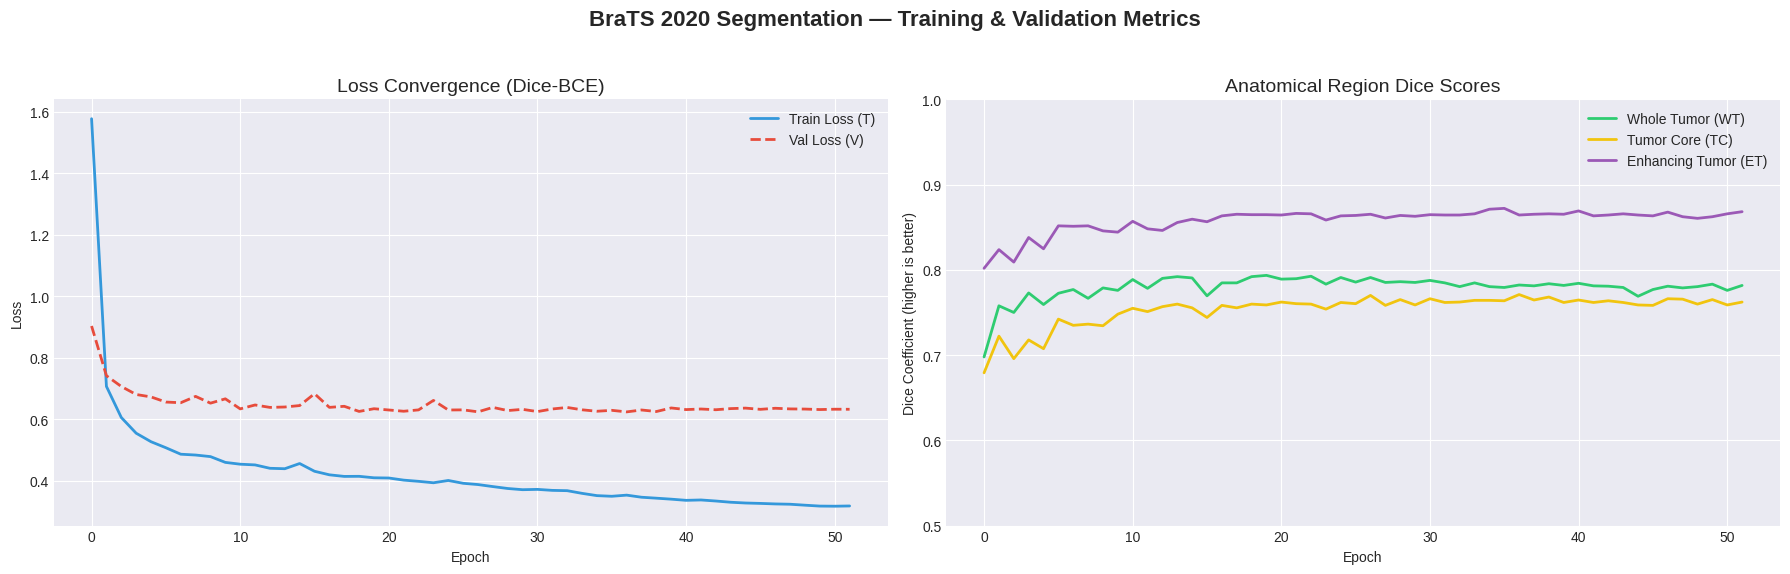

In [34]:
import matplotlib.pyplot as plt
import re
import numpy as np

# Your raw segmentation training logs
raw_text = """
321.7s	99	Ep 0 | T: 1.5771 | V: 0.9030 | WT: 0.6978 | TC: 0.6792 | ET: 0.8018 | P: 0/15
354.3s	100	Ep 1 | T: 0.7066 | V: 0.7413 | WT: 0.7578 | TC: 0.7222 | ET: 0.8237 | P: 0/15
387.0s	101	Ep 2 | T: 0.6055 | V: 0.7064 | WT: 0.7500 | TC: 0.6958 | ET: 0.8091 | P: 0/15
421.3s	102	Ep 3 | T: 0.5544 | V: 0.6803 | WT: 0.7729 | TC: 0.7178 | ET: 0.8379 | P: 0/15
454.2s	103	Ep 4 | T: 0.5267 | V: 0.6724 | WT: 0.7593 | TC: 0.7075 | ET: 0.8247 | P: 0/15
486.7s	104	Ep 5 | T: 0.5071 | V: 0.6557 | WT: 0.7725 | TC: 0.7422 | ET: 0.8516 | P: 0/15
521.7s	105	Ep 6 | T: 0.4861 | V: 0.6535 | WT: 0.7769 | TC: 0.7349 | ET: 0.8511 | P: 0/15
555.7s	106	Ep 7 | T: 0.4834 | V: 0.6741 | WT: 0.7666 | TC: 0.7363 | ET: 0.8516 | P: 0/15
591.2s	107	Ep 8 | T: 0.4783 | V: 0.6521 | WT: 0.7788 | TC: 0.7344 | ET: 0.8457 | P: 1/15
628.9s	108	Ep 9 | T: 0.4595 | V: 0.6662 | WT: 0.7759 | TC: 0.7480 | ET: 0.8442 | P: 0/15
665.7s	109	Ep 10 | T: 0.4536 | V: 0.6335 | WT: 0.7886 | TC: 0.7549 | ET: 0.8569 | P: 1/15
708.2s	110	Ep 11 | T: 0.4513 | V: 0.6462 | WT: 0.7783 | TC: 0.7510 | ET: 0.8481 | P: 0/15
744.7s	111	Ep 12 | T: 0.4403 | V: 0.6383 | WT: 0.7900 | TC: 0.7568 | ET: 0.8462 | P: 1/15
779.4s	112	Ep 13 | T: 0.4389 | V: 0.6396 | WT: 0.7920 | TC: 0.7598 | ET: 0.8555 | P: 2/15
813.5s	113	Ep 14 | T: 0.4558 | V: 0.6443 | WT: 0.7905 | TC: 0.7554 | ET: 0.8594 | P: 3/15
848.4s	114	Ep 15 | T: 0.4306 | V: 0.6828 | WT: 0.7695 | TC: 0.7441 | ET: 0.8564 | P: 4/15
884.0s	115	Ep 16 | T: 0.4191 | V: 0.6384 | WT: 0.7847 | TC: 0.7583 | ET: 0.8633 | P: 5/15
919.0s	116	Ep 17 | T: 0.4139 | V: 0.6419 | WT: 0.7847 | TC: 0.7554 | ET: 0.8652 | P: 6/15
953.7s	117	Ep 18 | T: 0.4142 | V: 0.6252 | WT: 0.7920 | TC: 0.7598 | ET: 0.8647 | P: 7/15
989.1s	118	Ep 19 | T: 0.4094 | V: 0.6340 | WT: 0.7935 | TC: 0.7588 | ET: 0.8647 | P: 0/15
1023.9s	119	Ep 20 | T: 0.4087 | V: 0.6299 | WT: 0.7891 | TC: 0.7622 | ET: 0.8643 | P: 1/15
1058.5s	120	Ep 21 | T: 0.4018 | V: 0.6258 | WT: 0.7896 | TC: 0.7603 | ET: 0.8662 | P: 2/15
1093.6s	121	Ep 22 | T: 0.3979 | V: 0.6302 | WT: 0.7925 | TC: 0.7598 | ET: 0.8657 | P: 3/15
1129.1s	122	Ep 23 | T: 0.3932 | V: 0.6610 | WT: 0.7832 | TC: 0.7539 | ET: 0.8584 | P: 4/15
1164.5s	123	Ep 24 | T: 0.4007 | V: 0.6299 | WT: 0.7910 | TC: 0.7617 | ET: 0.8633 | P: 5/15
1200.3s	124	Ep 25 | T: 0.3915 | V: 0.6303 | WT: 0.7856 | TC: 0.7603 | ET: 0.8638 | P: 6/15
1263.2s	125	Ep 26 | T: 0.3874 | V: 0.6239 | WT: 0.7910 | TC: 0.7700 | ET: 0.8652 | P: 7/15
1300.1s	126	Ep 27 | T: 0.3808 | V: 0.6383 | WT: 0.7852 | TC: 0.7583 | ET: 0.8608 | P: 0/15
1335.9s	127	Ep 28 | T: 0.3746 | V: 0.6280 | WT: 0.7861 | TC: 0.7651 | ET: 0.8638 | P: 1/15
1370.9s	128	Ep 29 | T: 0.3707 | V: 0.6320 | WT: 0.7852 | TC: 0.7588 | ET: 0.8628 | P: 2/15
1404.9s	129	Ep 30 | T: 0.3717 | V: 0.6247 | WT: 0.7876 | TC: 0.7661 | ET: 0.8647 | P: 3/15
1439.0s	130	Ep 31 | T: 0.3685 | V: 0.6332 | WT: 0.7847 | TC: 0.7617 | ET: 0.8643 | P: 4/15
1474.2s	131	Ep 32 | T: 0.3675 | V: 0.6381 | WT: 0.7803 | TC: 0.7622 | ET: 0.8643 | P: 5/15
1508.9s	132	Ep 33 | T: 0.3588 | V: 0.6305 | WT: 0.7847 | TC: 0.7642 | ET: 0.8657 | P: 6/15
1543.0s	133	Ep 34 | T: 0.3514 | V: 0.6258 | WT: 0.7803 | TC: 0.7642 | ET: 0.8711 | P: 7/15
1578.2s	134	Ep 35 | T: 0.3493 | V: 0.6288 | WT: 0.7793 | TC: 0.7637 | ET: 0.8721 | P: 8/15
1612.8s	135	Ep 36 | T: 0.3530 | V: 0.6237 | WT: 0.7822 | TC: 0.7710 | ET: 0.8643 | P: 9/15
1648.3s	136	Ep 37 | T: 0.3462 | V: 0.6299 | WT: 0.7812 | TC: 0.7646 | ET: 0.8652 | P: 0/15
1682.3s	137	Ep 38 | T: 0.3431 | V: 0.6249 | WT: 0.7837 | TC: 0.7681 | ET: 0.8657 | P: 1/15
1717.3s	138	Ep 39 | T: 0.3399 | V: 0.6365 | WT: 0.7817 | TC: 0.7617 | ET: 0.8652 | P: 2/15
1753.1s	139	Ep 40 | T: 0.3361 | V: 0.6312 | WT: 0.7842 | TC: 0.7646 | ET: 0.8691 | P: 3/15
1787.8s	140	Ep 41 | T: 0.3373 | V: 0.6331 | WT: 0.7812 | TC: 0.7617 | ET: 0.8633 | P: 4/15
1822.8s	141	Ep 42 | T: 0.3339 | V: 0.6307 | WT: 0.7808 | TC: 0.7637 | ET: 0.8643 | P: 5/15
1858.4s	142	Ep 43 | T: 0.3299 | V: 0.6344 | WT: 0.7793 | TC: 0.7617 | ET: 0.8657 | P: 6/15
1893.9s	143	Ep 44 | T: 0.3274 | V: 0.6360 | WT: 0.7690 | TC: 0.7588 | ET: 0.8643 | P: 7/15
1929.5s	144	Ep 45 | T: 0.3261 | V: 0.6320 | WT: 0.7769 | TC: 0.7583 | ET: 0.8633 | P: 8/15
1964.6s	145	Ep 46 | T: 0.3244 | V: 0.6355 | WT: 0.7808 | TC: 0.7661 | ET: 0.8677 | P: 9/15
1999.8s	146	Ep 47 | T: 0.3234 | V: 0.6334 | WT: 0.7788 | TC: 0.7656 | ET: 0.8623 | P: 10/15
2034.5s	147	Ep 48 | T: 0.3203 | V: 0.6329 | WT: 0.7803 | TC: 0.7598 | ET: 0.8604 | P: 11/15
2096.3s	148	Ep 49 | T: 0.3174 | V: 0.6313 | WT: 0.7832 | TC: 0.7651 | ET: 0.8623 | P: 12/15
2130.6s	149	Ep 50 | T: 0.3170 | V: 0.6324 | WT: 0.7759 | TC: 0.7588 | ET: 0.8657 | P: 13/15
2165.3s	150	Ep 51 | T: 0.3178 | V: 0.6322 | WT: 0.7817 | TC: 0.7622 | ET: 0.8682 | P: 14/15
"""

def plot_segmentation_metrics(text):
    epochs = []
    t_loss = []
    v_loss = []
    wt_dice = []
    tc_dice = []
    et_dice = []

    # Regex to find Ep, T, V, WT, TC, ET
    pattern = r"Ep\s+(\d+)\s+\|\s+T:\s+([\d.-]+)\s+\|\s+V:\s+([\d.-]+)\s+\|\s+WT:\s+([\d.-]+)\s+\|\s+TC:\s+([\d.-]+)\s+\|\s+ET:\s+([\d.-]+)"
    
    matches = re.findall(pattern, text)
    
    for m in matches:
        epochs.append(int(m[0]))
        t_loss.append(float(m[1]))
        v_loss.append(float(m[2]))
        wt_dice.append(float(m[3]))
        tc_dice.append(float(m[4]))
        et_dice.append(float(m[5]))

    # Sort by epoch
    idx = np.argsort(epochs)
    epochs = np.array(epochs)[idx]
    t_loss = np.array(t_loss)[idx]
    v_loss = np.array(v_loss)[idx]
    wt_dice = np.array(wt_dice)[idx]
    tc_dice = np.array(tc_dice)[idx]
    et_dice = np.array(et_dice)[idx]

    # Create Plot
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('BraTS 2020 Segmentation — Training & Validation Metrics', fontsize=16, fontweight='bold')

    # 1. Loss Plot (Training vs Validation)
    axes[0].plot(epochs, t_loss, label='Train Loss (T)', color='#3498db', linewidth=2)
    axes[0].plot(epochs, v_loss, label='Val Loss (V)', color='#e74c3c', linewidth=2, linestyle='--')
    axes[0].set_title('Loss Convergence (Dice-BCE)', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # 2. Dice Score Plot
    axes[1].plot(epochs, wt_dice, label='Whole Tumor (WT)', color='#2ecc71', linewidth=2)
    axes[1].plot(epochs, tc_dice, label='Tumor Core (TC)', color='#f1c40f', linewidth=2)
    axes[1].plot(epochs, et_dice, label='Enhancing Tumor (ET)', color='#9b59b6', linewidth=2)
    axes[1].set_title('Anatomical Region Dice Scores', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Coefficient (higher is better)')
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('segmentation_learning_curves.png', dpi=300)
    print("✅ Segmentation graph saved as 'segmentation_learning_curves.png'")
    plt.show()

# To run:
plot_segmentation_metrics(raw_text)

